In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
train_dir='/content/drive/MyDrive/MRI/Training'
test_dir='/content/drive/MyDrive/MRI/Testing'

train_paths=[]
train_label=[]

for label in os.listdir(train_dir):
  print(label)
  for img in os.listdir(os.path.join(train_dir,label)):
    train_paths.append(os.path.join(train_dir,label,img))
    train_label.append(label)

train_paths,train_label=shuffle(train_paths,train_label)

test_paths=[]
test_label=[]

for label in os.listdir(test_dir):
  print(label)
  for img in os.listdir(os.path.join(test_dir,label)):
    test_paths.append(os.path.join(test_dir,label,img))
    test_label.append(label)

train_paths,train_label=shuffle(train_paths,train_label)



notumor
pituitary
glioma
meningioma
meningioma
notumor
pituitary
glioma


In [9]:
os.listdir(train_dir)

['notumor', 'pituitary', 'glioma', 'meningioma']

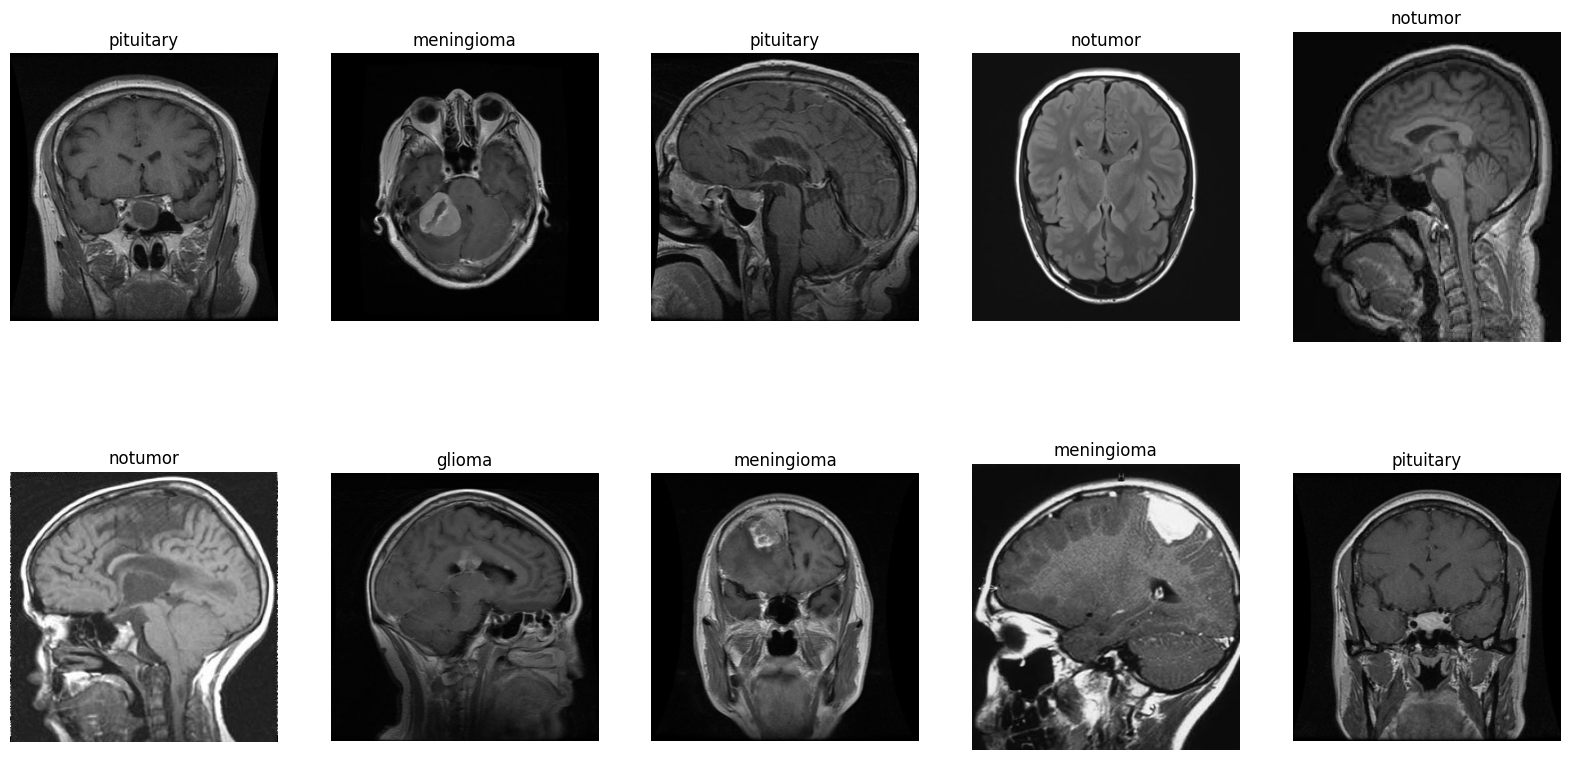

In [10]:
random_indices=random.sample(range(0,len(train_paths)),10)
fig,axes =plt.subplots(2,5,figsize=(20,10))
axes=axes.ravel()

for i,idx in enumerate(random_indices):
  axes[i].imshow(cv2.imread(train_paths[idx]))
  axes[i].set_title(train_label[idx])
  axes[i].axis('off')
plt.show()


image preprocessing


In [11]:
def augment_image(image):
  image=Image.fromarray(np.uint8(image))
  image=ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
  image=ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
  image=np.array(image)/255.0
  return image


def open_images(paths):
  images=[]
  for path in paths:
    img=cv2.imread(path)
    if img is not None:

      img = cv2.resize(img, (image_size, image_size))
      image=augment_image(img)
      images.append(image)
  return np.array(images)

def encode_label(labels):
  unique_labels=np.unique(labels)
  unique_labels=os.listdir(train_dir)
  encoded=[unique_labels.index(label) for label in labels]
  return np.array(encoded)


def datagen(paths,labels,batch_size=12):
  for i in range(0,len(paths),batch_size):
      batches_paths=paths[i:i+batch_size]
      batch_images=open_images(batches_paths)
      batch_labels=encode_label(labels[i:i+batch_size])
      yield batch_images,batch_labels

In [7]:
from tensorflow.keras.applications import VGG16

image_size=128
base_model=VGG16(input_shape=(image_size,image_size,3),include_top=False,weights='imagenet')




58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/model.h5")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [6]:
import os
print(os.listdir("/content"))

['.config', 'drive', 'sample_data']


In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Re-instantiate ModelCheckpoint and EarlyStopping callbacks
model_checkpoint_callback = ModelCheckpoint(
    filepath="/content/drive/MyDrive/model.keras",
    save_best_only=False, # Save model after each epoch
    save_freq='epoch',
    verbose=1
)

# early_stop was already defined in URhdYHFSRyZU
callbacks_list = [model_checkpoint_callback, early_stop]

# Resume training
history = model.fit(
    datagen(train_paths, train_label, batch_size=batch_size),
    steps_per_epoch=steps,
    epochs=epochs,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.3168 - sparse_categorical_accuracy: 0.8881
Epoch 1: saving model to /content/drive/MyDrive/model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 41s 145ms/step - loss: 0.3167 - sparse_categorical_accuracy: 0.8882
Epoch 2/5

Epoch 2: saving model to /content/drive/MyDrive/model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,sparse_categorical_accuracy
  current = self.get_monitor_value(logs)


280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0000e+00 - sparse_categorical_accuracy: 0.0000e+00
Epoch 3/5
  2/280 ━━━━━━━━━━━━━━━━━━━━ 23s 86ms/step - loss: 0.1172 - sparse_categorical_accuracy: 0.9750 
Epoch 3: saving model to /content/drive/MyDrive/model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1649 - sparse_categorical_accuracy: 0.9502  
Epoch 4/5
  2/280 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - loss: 0.0643 - sparse_categorical_accuracy: 0.9875
Epoch 4: saving model to /content/drive/MyDrive/model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0847 - sparse_categorical_accuracy: 0.9751  
Epoch 5/5
  2/280 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 0.0375 - sparse_categorical_accuracy: 1.0000
Epoch 5: saving model to /content/drive/MyDrive/model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0536 - sparse_categorical_accuracy: 1.0000  


In [14]:
from keras.src.backend.config import set_max_steps_per_epoch
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam

#freeze all layers
for layer in base_model.layers:
  layer.trainable=False
#set only last few layers
for layer in base_model.layers[-4:]:
  layer.trainable=True

#build model
model=Sequential()
model.add(Input(shape=(image_size,image_size,3)))
model.add(base_model)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4,activation='softmax')) #
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

batch_size=20
steps=int(len(train_paths)/batch_size)
epochs=5

#train
# Modified model.fit call to pass steps_per_epoch and epochs directly to fit method
ModelCheckpoint(
    "/content/drive/MyDrive/model.keras",
    save_best_only=False,
    save_freq='epoch'
)
history=model.fit(datagen(train_paths,train_label,batch_size=batch_size),
                  steps_per_epoch=steps,
                  epochs=epochs)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1269s 4s/step - loss: 0.7790 - sparse_categorical_accuracy: 0.6818
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 34us/step - loss: 0.0000e+00 - sparse_categorical_accuracy: 0.0000e+00
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step - loss: 0.3644 - sparse_categorical_accuracy: 0.8247
Epoch 4/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 221us/step - loss: 0.4284 - sparse_categorical_accuracy: 0.8251
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 208us/step - loss: 0.2811 - sparse_categorical_accuracy: 0.9253


In [4]:
import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle


In [3]:
import ipywidgets as widgets
import io
from PIL import Image, ImageEnhance
import tqdm
from sklearn.model_selection import train_test_split
import cv2
import shutil
import numpy as np
import tensorflow as tf
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',   # what to track
    patience=3,           # epochs to wait before stopping
    restore_best_weights=True
)

In [18]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,auc
from sklearn.preprocessing import label_binarize

test_images=open_images(test_paths)
test_labels=encode_label(test_label)

test_predictions=model.predict(test_images)
print("classification report:")
print(classification_report(test_labels,np.argmax(test_predictions,axis=1)))


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step
classification report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       400
           1       0.91      0.97      0.94       400
           2       0.94      0.69      0.80       400
           3       0.85      0.76      0.80       400

    accuracy                           0.86      1600
   macro avg       0.87      0.86      0.85      1600
weighted avg       0.87      0.86      0.85      1600



In [19]:
conf_matrix=confusion_matrix(test_labels,np.argmax(test_predictions,axis=1))
print(conf_matrix)

plt.figure(figsize=(8,6))


[[399   0   1   0]
 [  5 388   2   5]
 [ 61  11 278  50]
 [ 52  28  16 304]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [20]:
# Preferred: native Keras format (loads reliably in newer Keras/TensorFlow)
model.save('model.keras')

# Optional legacy export (may fail to load on some environments)
model.save('model.h5')

In [21]:
#load trained model
from tensorflow.keras.models import load_model
model=load_model('model.h5')

In [22]:
from keras.preprocessing.image import load_img,img_to_array

In [26]:
def detect_and_display(image_path, model):
  try:
    img_pil = load_img(image_path, target_size=(128, 128)) # PIL Image
    img_array = img_to_array(img_pil) # NumPy array, shape (128, 128, 3)

    # Normalize image to [0, 1] range, consistent with training data
    img_normalized = img_array / 255.0

    # Add batch dimension for prediction: shape (1, 128, 128, 3)
    img_for_prediction = np.expand_dims(img_normalized, axis=0)

    predictions = model.predict(img_for_prediction)
    predicted_class_index = np.argmax(predictions)

    class_labels = ['notumor', 'pituitary', 'glioma', 'meningioma']

    predicted_class = class_labels[predicted_class_index]
    confidence_score = predictions[0][predicted_class_index] # Get confidence for the predicted class

    print(f"Predicted Class: {predicted_class}")

    if predicted_class == 'notumor':
      print("No Tumor Detected")
    else:
      print(f"Tumor Detected: {predicted_class}")
      print(f"Confidence Score: {confidence_score*100:.2f}%")

    plt.imshow(img_normalized) # Display the normalized image
    plt.axis('off')
    plt.show()
  except Exception as e:
    print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Class: notumor
No Tumor Detected


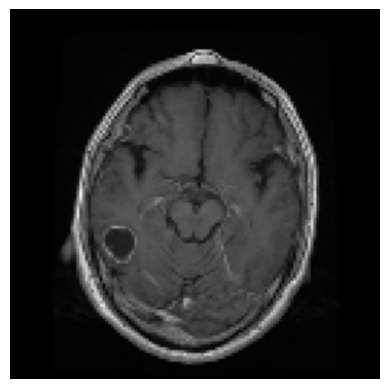

In [29]:
image_path='/content/drive/MyDrive/MRI/Testing/glioma/Te-gl_77.jpg'
detect_and_display(image_path,model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Class: meningioma
Tumor Detected: meningioma
Confidence Score: 99.89%


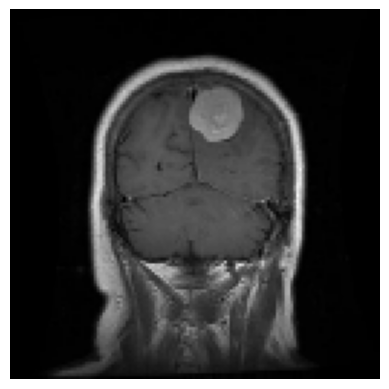

In [31]:
image_path='/content/drive/MyDrive/MRI/Testing/meningioma/Te-aug-me_76.jpg'
detect_and_display(image_path,model)